### 01: Import Paths and Modules

In [2]:
from pathlib import Path
import sys

project_root = Path("..").resolve()
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

print("project_root =", project_root)
print("src_dir      =", src_dir)

project_root = E:\UsersData\Desktop\tempest_amplitude
src_dir      = E:\UsersData\Desktop\tempest_amplitude\src


### 02: Import Basic Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### 03: Load TEMPEST Modules

In [4]:
from config_manager import load_config
from tempest_io import ensure_dir, save_uint8_png, save_npy, save_json, build_output_paths, read_bb_or_mat
from tempest_recon import (
    remove_dc,
    estimate_freq_offset,
    apply_freq_offset_correction,
    lowpass_filter,
    resample_to_pixel_rate,
    get_available_frame_count,
    extract_frame,
    make_iq_vis,
    make_amp_image,
    make_amp_gain_image,
    make_amp_log_gain_image,
)

### 04: Read Configuration

In [5]:
cfg = load_config(project_root / "configs" / "debug_single.json")
cfg

{'input': {'file_in': 'E:\\UsersData\\Desktop\\tempest_amplitude\\signals\\example.mat',
  'input_dir': 'E:\\UsersData\\Desktop\\tempest_amplitude\\signals',
  'pattern': '*.mat',
  'recursive': False},
 'output': {'output_dir': 'E:\\UsersData\\Desktop\\tempest_amplitude\\outputs\\run_debug',
  'save_complex_npy': True,
  'save_iq_png': True,
  'save_amp_png': True,
  'save_amp_gain_png': True,
  'save_amp_log_gain_png': True,
  'save_meta_json': True,
  'copy_used_config': True},
 'signal': {'Fs': 60000000.0,
  'pixel_rate': 148500000.0,
  'h_total': 2200,
  'v_total': 1125,
  'up': 99,
  'down': 40},
 'processing': {'BW': 16000000.0,
  'numtaps': 129,
  'dc_remove_len': 10000,
  'freq_est_m': 2000,
  'frame_idx': 0},
 'visualization': {'gain_linear': 3.0,
  'gain_log': 1.4,
  'eps': 1e-08,
  'percentile_low': 1,
  'percentile_high': 99}}

### 05: Extract Basic Parameters

In [6]:
file_in = cfg["input"]["file_in"]
output_dir = cfg["output"]["output_dir"]

signal_cfg = cfg["signal"]
proc_cfg = cfg["processing"]
vis_cfg = cfg["visualization"]
out_cfg = cfg["output"]

print("file_in   =", file_in)
print("output_dir=", output_dir)
print("frame_idx =", proc_cfg["frame_idx"])

file_in   = E:\UsersData\Desktop\tempest_amplitude\signals\example.mat
output_dir= E:\UsersData\Desktop\tempest_amplitude\outputs\run_debug
frame_idx = 0


### 06: Read Files and Check Raw Data

In [7]:
rx = read_bb_or_mat(file_in)

print("Loaded IQ:")
print("  shape =", rx.shape)
print("  dtype =", rx.dtype)
print("  samples =", len(rx))
print("  first 5 samples =", rx[:5])

Loaded IQ:
  shape = (6000000,)
  dtype = complex64
  samples = 6000000
  first 5 samples = [-0.00439453-0.04248047j -0.00634766+0.02685547j -0.01416016+0.00292969j
  0.04589844-0.03027344j  0.03125   +0.00585938j]


### 07: Main Process

In [8]:
# 1) DC removal
rx_dc = remove_dc(rx, proc_cfg["dc_remove_len"])

# 2) Frequency offset estimation
foff = estimate_freq_offset(rx_dc, signal_cfg["Fs"], proc_cfg["freq_est_m"])

# 3) Frequency offset correction
rx_corr = apply_freq_offset_correction(rx_dc, signal_cfg["Fs"], foff)

# 4) Lowpass filter
rx_filt = lowpass_filter(
    rx_corr,
    signal_cfg["Fs"],
    proc_cfg["BW"],
    proc_cfg["numtaps"],
)

# 5) Resample
rx_pix = resample_to_pixel_rate(
    rx_filt,
    signal_cfg["up"],
    signal_cfg["down"],
)

# 6) Frame stats
available_frames = get_available_frame_count(
    rx_pix,
    signal_cfg["h_total"],
    signal_cfg["v_total"],
)

# 7) Extract target frame
img_complex = extract_frame(
    rx_pix,
    signal_cfg["h_total"],
    signal_cfg["v_total"],
    proc_cfg["frame_idx"],
)

print("Estimated freq offset (Hz):", foff)
print("Resampled samples         :", len(rx_pix))
print("Available frames          :", available_frames)
print("Extracted frame shape     :", img_complex.shape)

Estimated freq offset (Hz): -7205.98046875
Resampled samples         : 14850000
Available frames          : 6
Extracted frame shape     : (1125, 2200)


### 08: Images Output

In [9]:
iq_vis = make_iq_vis(
    img_complex,
    vis_cfg["percentile_low"],
    vis_cfg["percentile_high"],
    vis_cfg["eps"],
)

amp_img = make_amp_image(
    img_complex,
    vis_cfg["percentile_low"],
    vis_cfg["percentile_high"],
    vis_cfg["eps"],
)

amp_gain_img = make_amp_gain_image(
    img_complex,
    vis_cfg["gain_linear"],
    vis_cfg["percentile_low"],
    vis_cfg["percentile_high"],
    vis_cfg["eps"],
)

amp_log_gain_img = make_amp_log_gain_image(
    img_complex,
    vis_cfg["gain_log"],
    vis_cfg["percentile_low"],
    vis_cfg["percentile_high"],
    vis_cfg["eps"],
)

### 09: Image Display

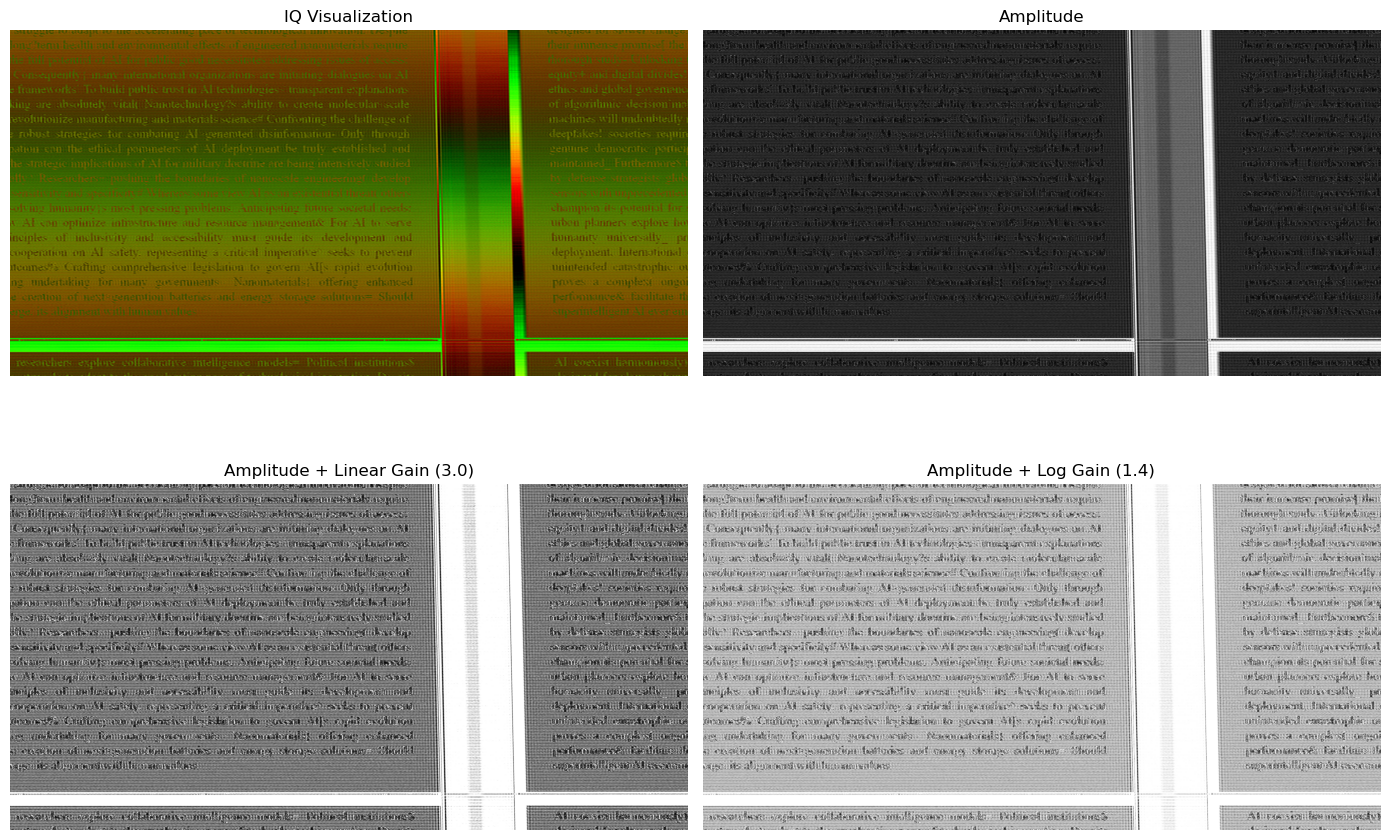

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(iq_vis)
axes[0, 0].set_title("IQ Visualization")
axes[0, 0].axis("off")

axes[0, 1].imshow(amp_img, cmap="gray")
axes[0, 1].set_title("Amplitude")
axes[0, 1].axis("off")

axes[1, 0].imshow(amp_gain_img, cmap="gray")
axes[1, 0].set_title(f"Amplitude + Linear Gain ({vis_cfg['gain_linear']})")
axes[1, 0].axis("off")

axes[1, 1].imshow(amp_log_gain_img, cmap="gray")
axes[1, 1].set_title(f"Amplitude + Log Gain ({vis_cfg['gain_log']})")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### 10: Save Images

In [ ]:
save_outputs = True

if save_outputs:
    out_dir = ensure_dir(output_dir)
    paths = build_output_paths(file_in, out_dir)

    if out_cfg["save_complex_npy"]:
        save_npy(paths["npy"], img_complex)

    if out_cfg["save_iq_png"]:
        save_uint8_png(paths["iq_png"], iq_vis)

    if out_cfg["save_amp_png"]:
        save_uint8_png(paths["amp_png"], amp_img)

    if out_cfg["save_amp_gain_png"]:
        save_uint8_png(paths["amp_gain_png"], amp_gain_img)

    if out_cfg["save_amp_log_gain_png"]:
        save_uint8_png(paths["amp_log_gain_png"], amp_log_gain_img)

    if out_cfg["save_meta_json"]:
        meta = {
            "input_file": str(file_in),
            "loaded_samples": int(len(rx)),
            "resampled_samples": int(len(rx_pix)),
            "available_frames": int(available_frames),
            "frame_idx": int(proc_cfg["frame_idx"]),
            "freq_offset_hz": float(foff),
            "config": cfg,
        }
        save_json(paths["meta_json"], meta)

    print("Saved outputs to:", paths["sample_dir"])